In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Multilayer Perceptrons

In that section, we introduced
softmax regression,
implementing the algorithm from scratch
(that section) and using high-level APIs
(that section). This allowed us to
train classifiers capable of recognizing
10 categories of clothing from low-resolution images.
Along the way, we learned how to wrangle data,
coerce our outputs into a valid probability distribution,
apply an appropriate loss function,
and minimize it with respect to our model's parameters.
Now that we have mastered these mechanics
in the context of simple linear models,
we can launch our exploration of deep neural networks,
the comparatively rich class of models
with which this book is primarily concerned.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
from jax import numpy as jnp
from jax import grad, vmap
import numpy as onp

## Hidden Layers

We described affine transformations in
that section as
linear transformations with added bias.
To begin, recall the model architecture
corresponding to our softmax regression example,
illustrated in the figure.
This model maps inputs directly to outputs
via a single affine transformation,
followed by a softmax operation.
If our labels truly were related
to the input data by a simple affine transformation,
then this approach would be sufficient.
However, linearity (in affine transformations) is a *strong* assumption.

### Limitations of Linear Models

For example, linearity implies the *weaker*
assumption of *monotonicity*, i.e.,
that any increase in our feature must
either always cause an increase in our model's output
(if the corresponding weight is positive),
or always cause a decrease in our model's output
(if the corresponding weight is negative).
Sometimes that makes sense.
For example, if we were trying to predict
whether an individual will repay a loan,
we might reasonably assume that all other things being equal,
an applicant with a higher income
would always be more likely to repay
than one with a lower income.
While monotonic, this relationship likely
is not linearly associated with the probability of
repayment. An increase in income from \$0 to \$50,000
likely corresponds to a bigger increase
in likelihood of repayment
than an increase from \$1 million to \$1.05 million.
One way to handle this might be to postprocess our outcome
such that linearity becomes more plausible,
by passing the outcome through the logistic function (i.e., modeling the log-odds linearly).

Note that we can easily come up with examples
that violate monotonicity.
Say for example that we want to predict health as a function
of body temperature.
For individuals with a normal body temperature
above 37°C (98.6°F),
higher temperatures indicate greater risk.
However, if the body temperatures drops
below 37°C, lower temperatures indicate greater risk!
Again, we might resolve the problem
with some clever preprocessing, such as using the distance from 37°C
as a feature.


But what about classifying images of cats and dogs?
Should increasing the intensity
of the pixel at location (13, 17)
always increase (or always decrease)
the likelihood that the image depicts a dog?
Reliance on a linear model corresponds to the implicit
assumption that the only requirement
for differentiating cats and dogs is to assess
the brightness of individual pixels.
This approach is doomed to fail in a world
where inverting an image preserves the category.

And yet despite the apparent absurdity of linearity here,
as compared with our previous examples,
it is less obvious that we could address the problem
with a simple preprocessing fix.
That is, because the significance of any pixel
depends in complex ways on its context
(the values of the surrounding pixels).
While there might exist a representation of our data
that would take into account
the relevant interactions among our features,
on top of which a linear model would be suitable,
we simply do not know how to calculate it by hand.
With deep neural networks, we use observational data
to jointly learn both a representation via hidden layers
and a linear predictor that acts upon that representation.

This problem of nonlinearity has been studied for at least a
century [@Fisher.1928]. For instance, decision trees
in their most basic form use a sequence of binary decisions to
decide upon class membership [@quinlan2014c4]. Likewise, kernel
methods have been used for many decades to model nonlinear dependencies
[@Aronszajn.1950], including nonparametric spline models
[@Wahba.1990]. It is also something that the brain solves
quite naturally. After all, neurons feed into other neurons which,
in turn, feed into other neurons again [@Cajal.Azoulay.1894].
Consequently we have a sequence of relatively simple transformations.

### Incorporating Hidden Layers

We can overcome the limitations of linear models
by incorporating one or more hidden layers.
The easiest way to do this is to stack
many fully connected layers on top of one another.
Each layer feeds into the layer above it,
until we generate outputs.
We can think of the first $L-1$ layers
as our representation and the final layer
as our linear predictor.
This architecture is commonly called
a *multilayer perceptron*,
often abbreviated as *MLP* (the figure).

![An MLP with a hidden layer of five hidden units.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mlp.svg)

This MLP has four inputs, three outputs,
and its hidden layer contains five hidden units.
Since the input layer does not involve any calculations,
producing outputs with this network
requires implementing the computations
for both the hidden and output layers;
thus, the number of layers in this MLP is two.
Note that both layers are fully connected.
Every input influences every neuron in the hidden layer,
and each of these in turn influences
every neuron in the output layer. Alas, we are not quite
done yet.

### From Linear to Nonlinear

As before, we denote by the matrix $\mathbf{X} \in \mathbb{R}^{n \times d}$
a minibatch of $n$ examples where each example has $d$ inputs (features).
For a one-hidden-layer MLP whose hidden layer has $h$ hidden units,
we denote by $\mathbf{H} \in \mathbb{R}^{n \times h}$
the outputs of the hidden layer, which are
*hidden representations*.
Since the hidden and output layers are both fully connected,
we have hidden-layer weights $\mathbf{W}^{(1)} \in \mathbb{R}^{d \times h}$ and biases $\mathbf{b}^{(1)} \in \mathbb{R}^{1 \times h}$
and output-layer weights $\mathbf{W}^{(2)} \in \mathbb{R}^{h \times q}$ and biases $\mathbf{b}^{(2)} \in \mathbb{R}^{1 \times q}$.
This allows us to calculate the outputs $\mathbf{O} \in \mathbb{R}^{n \times q}$
of the one-hidden-layer MLP as follows:

$$
\begin{aligned}
    \mathbf{H} & = \mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}, \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.
\end{aligned}
$$

Note that after adding the hidden layer,
our model now requires us to track and update
additional sets of parameters.
So what have we gained in exchange?
You might be surprised to find out
that (in the model defined above) *we
gain nothing for our troubles*!
The reason is plain.
The hidden units above are given by
an affine function of the inputs,
and the outputs (pre-softmax) are just
an affine function of the hidden units.
An affine function of an affine function
is itself an affine function.
Moreover, our linear model was already
capable of representing any affine function.

To see this formally we can just collapse out the hidden layer in the above definition,
yielding an equivalent single-layer model with parameters
$\mathbf{W} = \mathbf{W}^{(1)}\mathbf{W}^{(2)}$ and $\mathbf{b} = \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)}$:

$$
\mathbf{O} = (\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})\mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W}^{(1)}\mathbf{W}^{(2)} + \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W} + \mathbf{b}.
$$

In order to realize the potential of multilayer architectures,
we need one more key ingredient: a
nonlinear *activation function* $\sigma$
to be applied to each hidden unit
following the affine transformation. For instance, a popular
choice is the ReLU (rectified linear unit) activation function [@Nair.Hinton.2010],
operating on its arguments elementwise.
The outputs of activation functions $\sigma(\cdot)$
are called *activations*.
In general, with activation functions in place,
it is no longer possible to collapse our MLP into a linear model:

$$
\begin{aligned}
    \mathbf{H} & = \sigma(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}), \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.\\
\end{aligned}
$$

Since each row in $\mathbf{X}$ corresponds to an example in the minibatch,
with some abuse of notation, we define the nonlinearity
$\sigma$ to apply to its inputs in a rowwise fashion,
i.e., one example at a time.
Note that we used the same notation for softmax
when we denoted a rowwise operation in that section.
Quite frequently the activation functions we use apply elementwise, a special
case of rowwise. That means that after computing the linear portion of the layer,
we can calculate each activation
without looking at the values taken by the other hidden units.

To build more general MLPs, we can continue stacking
such hidden layers,
e.g., $\mathbf{H}^{(1)} = \sigma_1(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})$
and $\mathbf{H}^{(2)} = \sigma_2(\mathbf{H}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)})$,
one atop another, yielding ever more expressive models.

### A Concrete Win: XOR

The collapse argument above told us what a hidden layer *cannot* do
without a nonlinearity. Let's now see what one *can* do once the
nonlinearity is in place, using the smallest problem that defeats every
linear model: the *exclusive-or* (XOR) function. Place four points at the
corners of the unit square and label each by whether its two coordinates
*differ*: $(0,0)$ and $(1,1)$ get label $0$, while $(0,1)$ and $(1,0)$ get
label $1$. As the figure shows on the left, the two classes
sit on opposite diagonals, so no straight line can put one class on each
side. A linear classifier is provably helpless here, no matter how we
choose its weights.

![XOR is not linearly separable, but one ReLU hidden layer makes it so. Left: the four corners of the unit square, coloured by the XOR label (the digit on each marker); the two classes lie on opposite diagonals, so any line misclassifies a corner. Right: the same four points after the hidden map $\mathbf{h} = \operatorname{ReLU}(\mathbf{x}\mathbf{W}^{(1)} + \mathbf{b}^{(1)})$ with $\mathbf{W}^{(1)} = \left(\begin{smallmatrix}1 & 1\\ 1 & 1\end{smallmatrix}\right)$ and $\mathbf{b}^{(1)} = (0, -1)$. The two class-1 corners are folded onto the *same* point $(1,0)$, and the cloud becomes linearly separable: the output neuron $h_1 - 2h_2$ now realizes XOR.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-mlp-xor.svg)

A single hidden layer with just two ReLU units solves it. The trick is
that the hidden layer is free to *re-represent* the inputs, and a clever
representation can fold the two awkward corners together. The classic
choice (see @Goodfellow.Bengio.Courville.2016, Chapter 6) uses

$$\mathbf{W}^{(1)} = \begin{pmatrix} 1 & 1 \\ 1 & 1 \end{pmatrix},
  \quad \mathbf{b}^{(1)} = \begin{pmatrix} 0 & -1 \end{pmatrix},
  \quad \mathbf{w}^{(2)} = \begin{pmatrix} 1 \\ -2 \end{pmatrix},
  \quad b^{(2)} = 0,$$

with a ReLU on the hidden layer. The first hidden unit fires for any
"active" input; the second only fires when *both* coordinates are on,
and subtracting twice the second unit cancels the lone case the first
unit gets wrong. The right panel of the figure plots the
hidden representation: the two label-1 corners land on top of each other
at $(1,0)$, after which a single line separates the classes. Let's verify
that this hand-built network computes XOR exactly on all four inputs.

In [2]:
X = onp.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
W1 = onp.array([[1., 1.], [1., 1.]])
b1 = onp.array([0., -1.])
w2 = onp.array([[1.], [-2.]])
H = onp.maximum(X @ W1 + b1, 0)
O = (H @ w2).squeeze()
onp.column_stack([X, (O > 0.5).astype(float)])

array([[0., 0., 0.],
       [0., 1., 1.],
       [1., 0., 1.],
       [1., 1., 0.]])

The third column is exactly the XOR of the first two. We *constructed* the
weights here, but the whole point of the rest of this book is that
optimization can *discover* such representations from data. The XOR fix
generalizes: stack nonlinear hidden layers and the network can carve the
input space into arbitrarily complicated regions.
To watch that discovery happen live, try the XOR and spiral datasets at the
[TensorFlow Playground](https://playground.tensorflow.org/), varying the
number of hidden units and layers as you go.

### Universal Approximators

How powerful is a deep network? The universal approximation theorem gives a
sharp answer. It says that even a single-hidden-layer
network, given enough hidden units and the right weights, can approximate any
continuous function on a bounded domain to arbitrary accuracy. This was proven
in several settings: @Cybenko.1989 did it for sigmoid activations,
@micchelli1984interpolation for radial basis function networks (a single
hidden layer), and the
result was soon generalized: @Hornik.1991 covered every bounded,
non-constant activation, and @Leshno.Lin.Pinkus.ea.1993 extended it to
any activation that is not a polynomial, a form that also covers the unbounded
ReLU. The conclusion therefore does not hinge on which of ReLU, sigmoid, or tanh
we pick.

To see why such a theorem should be *plausible*, set the citations aside and
consider a one-hidden-layer ReLU network on the real line. Each hidden unit
contributes $a_k \operatorname{ReLU}(w_k x + b_k)$ to the output: a *hinge*,
flat on one side of the joint at $x = -b_k/w_k$ and linear on the other. The
network's output is a sum of $D$ such hinges, so it is a continuous piecewise
linear function whose slope can change only at a joint: with $D$ hidden units it
has at most $D$ joints and hence at most $D+1$ linear pieces. Seen this way,
approximating a continuous function is no more mysterious than approximating a
curve with a polyline: place enough joints in the right locations and pick the
right slopes, and the error shrinks as finely as we please
(the figure). The exponential-width caveat below is
visible here too: a very wiggly target needs a joint for every wiggle, one
hidden unit apiece.

![Universal approximation, one hinge at a time. Left: each of the three hidden units contributes a single hinge $a_k \operatorname{ReLU}(x - t_k)$ whose joint $t_k$ is marked on the horizontal axis. Right: adding the hinges to a base line yields a piecewise linear function with $D+1 = 4$ pieces (blue) that tracks the smooth target (gray); the shaded band is the approximation error, which shrinks as more joints are added.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-mlp-uat-hinges.svg)

Width, however, buys pieces only *linearly*: one extra unit, one extra joint.
Depth is different. A second hidden layer applies its hinges not to $x$ but to
the piecewise linear output of the first layer, and composing with a hinge
*folds the graph*: every existing piece that crosses the new joint is split in
two. Each added layer can therefore roughly *double* the number of linear
pieces, so $k$ layers of width $D$ can produce on the order of
$(D+1)\,2^{k-1}$ pieces, where matching that count with a single hidden layer
would require exponentially many units. This multiplicative-versus-additive gap
is the essence of why depth pays. Both claims are easy to check numerically:
below we evaluate randomly initialized ReLU MLPs on a dense one-dimensional
grid, detect where the slope changes, and count the linear pieces.

In [3]:
def count_pieces(width, depth, rng, n=100001):
    x = onp.linspace(-4, 4, n).reshape(-1, 1)
    h = x
    for _ in range(depth):
        h = onp.maximum(h @ rng.standard_normal((h.shape[1], width))
                        + rng.standard_normal(width), 0)
    y = (h @ rng.standard_normal((width, 1))).squeeze()
    slope = onp.diff(y)
    tol = 1e-8 * onp.abs(slope).max() + 1e-12 * onp.abs(y).max()
    change = onp.abs(onp.diff(slope)) > tol
    new = change & ~onp.concatenate([[False], change[:-1]])
    return int(new.sum()) + 1
rng = onp.random.default_rng(0)
for depth in (1, 2, 3):
    mean = [round(sum(count_pieces(w, depth, rng) for _ in range(20)) / 20, 1)
            for w in (2, 4, 8, 16)]
    print(f'depth {depth}: mean pieces = {mean},  D+1 = {[3, 5, 9, 17]}')

depth 1: mean pieces = [2.8, 4.5, 7.8, 14.3],  D+1 = [3, 5, 9, 17]


depth 2: mean pieces = [3.2, 7.5, 14.2, 27.8],  D+1 = [3, 5, 9, 17]


depth 3: mean pieces = [3.0, 8.9, 19.5, 39.5],  D+1 = [3, 5, 9, 17]


The first row confirms the counting argument: with one hidden layer of width
$D$, the piece count never exceeds $D+1$ (and typically comes close to it).
The later rows show what happened for these seeded random networks: at each
width, adding a layer increased the average piece count by a factor rather than
by a fixed amount. This experiment does not establish a maximal count. Random
weights fold less aggressively than hand-constructed networks used in depth
separation results [@Telgarsky.2016]; those constructions, rather than the
sample averages above, establish the expressivity claim.

It is tempting to read this as "one hidden layer is all you ever need," but the
theorem is more modest than it sounds, and three caveats matter
(@Goodfellow.Bengio.Courville.2016, Chapter 6). First, it guarantees
that a good approximation *exists*; it says nothing about whether gradient
descent will *find* it. Second, even a network that fits the training data
perfectly may fail to *generalize* to new examples. Third, the promised single
layer can be impractically wide: matching a target may require *exponentially*
many hidden units. You might think of your neural network as being a bit like
the C programming language. The language, like any other modern language, is
capable of expressing any computable program, but actually coming up with a
program that meets your specifications is the hard part.

So the theorem tells us deep networks are expressive enough; it does not tell us
they are the right tool, nor how to build them. For some problems other methods
fit better (kernel methods, for instance, can solve regression problems exactly
[@Kimeldorf.Wahba.1971; @Scholkopf.Herbrich.Smola.2001]). Where a shallow
network would need exponential width, a *deep* one
can often represent the same function far more compactly, trading width for depth
[@Montufar.Pascanu.Cho.ea.2014; @Telgarsky.2016]. This is one reason practitioners reach for depth
rather than sheer width. The folding picture sketched above is the heart of
these depth-separation results; exercise 6 asks you to turn it into an
argument.


## Activation Functions

Activation functions are (almost everywhere) differentiable operators for transforming
pre-activation signals to outputs, introducing nonlinearity into the network.
Because activation functions are fundamental to deep learning,
let's briefly survey some common ones.

### ReLU Function

The most popular choice,
due to both simplicity of implementation and
its good performance on a variety of predictive tasks,
is the *rectified linear unit* (*ReLU*) [@Nair.Hinton.2010].
ReLU provides a very simple nonlinear transformation.
Given an element $x$, the function is defined
as the maximum of that element and $0$:

$$\operatorname{ReLU}(x) = \max(x, 0).$$

Informally, the ReLU function retains only positive
elements and discards all negative elements
by setting the corresponding activations to 0.
To gain some intuition, we can plot the function.
As you can see, the activation function is piecewise linear.

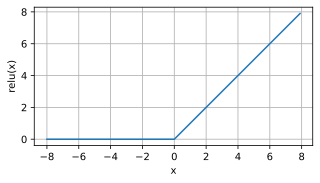

In [4]:
x = jnp.arange(-8.0, 8.0, 0.1)
y = jax.nn.relu(x)
d2l.plot(x, y, 'x', 'relu(x)', figsize=(5, 2.5))

When the input is negative,
the derivative of the ReLU function is 0,
and when the input is positive,
the derivative of the ReLU function is 1.
Note that the ReLU function is not differentiable
when the input takes value precisely equal to 0.
The libraries used here return a derivative of 0 at the origin, one valid
subgradient convention. For continuously distributed preactivations the choice
affects a probability-zero event. Exact zeros do occur in computation, for
example from zero-initialized biases or a preceding ReLU, and in such degenerate
cases the convention can change whether a unit begins to move.
We plot the derivative of the ReLU function below.

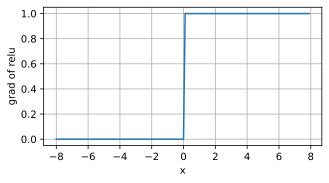

In [5]:
grad_relu = vmap(grad(jax.nn.relu))
d2l.plot(x, grad_relu(x), 'x', 'grad of relu', figsize=(5, 2.5))

The reason for using ReLU is that
its derivatives are particularly well behaved:
either they vanish or they just let the argument through.
This makes optimization better behaved
and it mitigated the well-documented problem
of vanishing gradients that plagued
previous versions of neural networks (more on this later).

This same flatness has a downside, however. Because the gradient is exactly
zero for negative inputs, a unit whose pre-activation is pushed negative for
every training example receives no gradient and stops updating: it becomes a
permanently silent *dead ReLU*. To keep gradient flowing in that regime, a
number of variants let a little signal through on the left. The best known is
the *parametrized ReLU* (*pReLU*) [@He.Zhang.Ren.ea.2015], which adds a
linear term so some information still gets through, even when the argument is
negative:

$$\operatorname{pReLU}(x) = \max(0, x) + \alpha \min(0, x).$$

Here $\alpha$ is a small slope (fixed for *leaky* ReLU, learned for pReLU).

### Sigmoid Function

The *sigmoid function* transforms those inputs
whose values lie in the domain $\mathbb{R}$,
to outputs that lie on the interval (0, 1).
For that reason, the sigmoid is
often called a *squashing function*:
it squashes any input in the range (-inf, inf)
to some value in the range (0, 1):

$$\operatorname{sigmoid}(x) = \frac{1}{1 + \exp(-x)}.$$

In the earliest neural networks, scientists
were interested in modeling biological neurons
that either *fire* or *do not fire*.
Thus the pioneers of this field,
going all the way back to McCulloch and Pitts,
the inventors of the artificial neuron,
focused on thresholding units [@McCulloch.Pitts.1943].
A thresholding activation takes value 0
when its input is below some threshold
and value 1 when the input exceeds the threshold.

When attention shifted to gradient-based learning,
the sigmoid function was a natural choice
because it is a smooth, differentiable
approximation to a thresholding unit.
Sigmoids are still widely used as
activation functions on the output units
when we want to interpret the outputs as probabilities
for binary classification problems: you can think of the sigmoid as a special case of the softmax, namely the softmax over the two logits $\{x, 0\}$.
However, the sigmoid has largely been replaced
by the simpler and more easily trainable ReLU
for most use in hidden layers. Much of this has to do
with the fact that the sigmoid poses challenges for optimization
[@LeCun.Bottou.Orr.ea.1998] since its gradient vanishes for large positive *and* negative arguments.
This can lead to plateaus that are difficult to escape from.
Nonetheless sigmoids are important. In later chapters (e.g., that section) on recurrent neural networks,
we will describe architectures that use sigmoid units
to control the flow of information across time.

Below, we plot the sigmoid function.
Note that when the input is close to 0,
the sigmoid function approaches
a linear transformation.

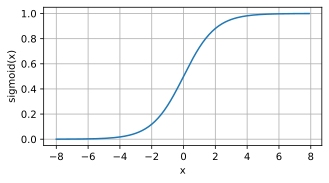

In [6]:
y = jax.nn.sigmoid(x)
d2l.plot(x, y, 'x', 'sigmoid(x)', figsize=(5, 2.5))

The derivative of the sigmoid function is given by the following equation:

$$\frac{d}{dx} \operatorname{sigmoid}(x) = \frac{\exp(-x)}{(1 + \exp(-x))^2} = \operatorname{sigmoid}(x)\left(1-\operatorname{sigmoid}(x)\right).$$


The derivative of the sigmoid function is plotted below.
Note that when the input is 0,
the derivative of the sigmoid function
reaches a maximum of 0.25.
As the input diverges from 0 in either direction,
the derivative approaches 0.

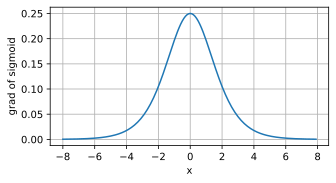

In [7]:
grad_sigmoid = vmap(grad(jax.nn.sigmoid))
d2l.plot(x, grad_sigmoid(x), 'x', 'grad of sigmoid', figsize=(5, 2.5))

### Tanh Function

Like the sigmoid function, the tanh (hyperbolic tangent)
function also squashes its inputs,
transforming them into elements on the interval between $-1$ and $1$:

$$\operatorname{tanh}(x) = \frac{1 - \exp(-2x)}{1 + \exp(-2x)}.$$

We plot the tanh function below. Note that as input nears 0, the tanh function approaches a linear transformation. Although the shape of the function is similar to that of the sigmoid function, the tanh function exhibits point symmetry about the origin of the coordinate system.

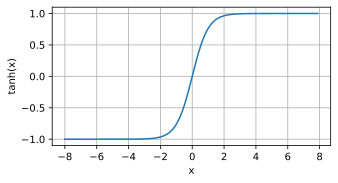

In [8]:
y = jax.nn.tanh(x)
d2l.plot(x, y, 'x', 'tanh(x)', figsize=(5, 2.5))

The derivative of the tanh function is:

$$\frac{d}{dx} \operatorname{tanh}(x) = 1 - \operatorname{tanh}^2(x).$$

It is plotted below.
As the input nears 0,
the derivative of the tanh function approaches a maximum of 1.
And as we saw with the sigmoid function,
as input moves away from 0 in either direction,
the derivative of the tanh function approaches 0.

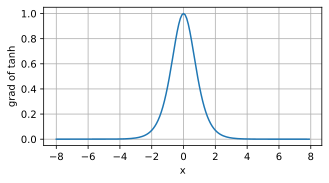

In [9]:
grad_tanh = vmap(grad(jax.nn.tanh))
d2l.plot(x, grad_tanh(x), 'x', 'grad of tanh', figsize=(5, 2.5))

## Summary and Discussion

We now know how to incorporate nonlinearities
to build expressive multilayer neural network architectures.
Your knowledge already puts you in command of a toolkit
much like that of a practitioner circa 1990, except that you can lean on
powerful open-source frameworks to build models in a few lines of code,
rather than coding up layers and their derivatives by hand in C or Fortran.

A key reason ReLU displaced sigmoid and tanh in hidden layers is that it
is so much more amenable to optimization. One could argue that this was one
of the innovations that helped the resurgence of deep learning in the early
2010s. Research on activation functions has not stopped, though, and you will
meet newer ones once we reach the Transformer architectures later in the book.
The most common are *GELU* (Gaussian error linear unit), $x \Phi(x)$, where
$\Phi$ is the standard Gaussian cumulative distribution function
[@Hendrycks.Gimpel.2016], used in BERT and GPT-2-style models; *Swish*,
$x \operatorname{sigmoid}(\beta x)$ [@Ramachandran.Zoph.Le.2017]; and
*SwiGLU* [@Shazeer.2020], a gated variant that is the default feedforward nonlinearity in
recent large language models such as PaLM, LLaMA, and Mistral. For now, ReLU
remains the sensible default for the models we build next.

## Exercises

1. Show that adding layers to a *linear* deep network, i.e., a network without
   nonlinearity $\sigma$ can never increase the expressive power of the network.
   Give an example where it actively reduces it.
1. Find weights for a two-hidden-unit ReLU network that computes XOR, and verify
   them on the four inputs. (You may reuse the construction in
   the figure, but try to derive your own first.) Can a *single*
   ReLU unit compute XOR? Why or why not?
1. Compute the derivative of the pReLU activation function.
1. Compute the derivative of the Swish activation function $x \operatorname{sigmoid}(\beta x)$.
1. Show that an MLP using only ReLU (or pReLU) constructs a
   continuous piecewise linear function.
1. Explain intuitively why composing ReLU layers can roughly *double* the number
   of linear pieces the network represents with each added layer, so that depth
   buys exponentially many pieces while width buys only linearly many. (This is
   the depth-versus-width gap behind the universal-approximation caveat above.)
1. Sigmoid and tanh are very similar.
    1. Show that $\operatorname{tanh}(x) + 1 = 2 \operatorname{sigmoid}(2x)$.
    1. Prove that the function classes parametrized by both nonlinearities are identical. Hint: affine layers have bias terms, too.
1. Assume that we have a nonlinearity that applies to one minibatch at a time, such as the batch normalization [@Ioffe.Szegedy.2015] (covered in that section). What kinds of problems do you expect this to cause?
1. Provide an example where the gradients vanish for the sigmoid activation function.

[Discussions](https://d2l.discourse.group/t/17984)